In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 100              # number of time periods (days)
start_price = 100
mu = 0.0005          # drift (average return)
sigma = 0.01         # volatility

# Simulate log returns
returns = np.random.normal(mu, sigma, n)

# Generate prices
prices = start_price * np.exp(np.cumsum(returns))

df = pd.DataFrame({'Close': prices})
df['Open'] = df['Close'].shift(1)
df.iloc[0, df.columns.get_loc('Open')] = start_price

In [2]:
high_noise = np.random.uniform(0, 0.02, n)
low_noise = np.random.uniform(0, 0.02, n)

df['High'] = df[['Open', 'Close']].max(axis=1) * (1 + high_noise)
df['Low'] = df[['Open', 'Close']].min(axis=1) * (1 - low_noise)


In [ ]:
df = df[['Open', 'High', 'Low', 'Close']]

In [4]:
%pip install mplfinance


Note: you may need to restart the kernel to use updated packages.


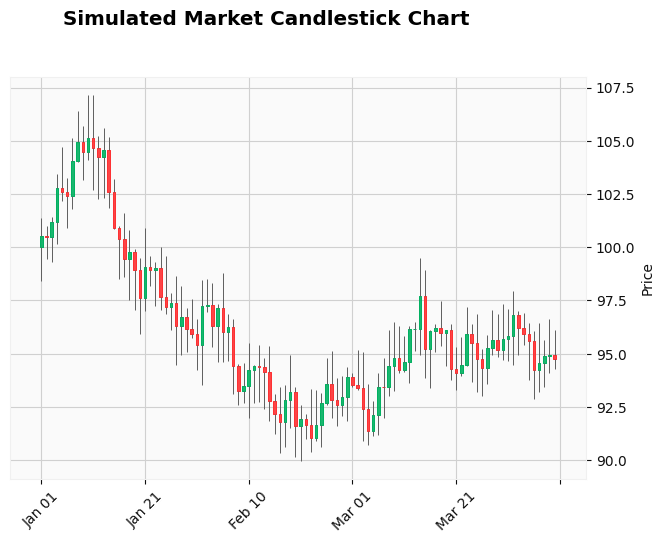

In [6]:
import mplfinance as mpf

df.index = pd.date_range(
    start="2024-01-01",
    periods=len(df),
    freq="D"
)

mpf.plot(
    df,
    type='candle',
    style='yahoo',
    title='Simulated Market Candlestick Chart',
    ylabel='Price',
    volume=False
)


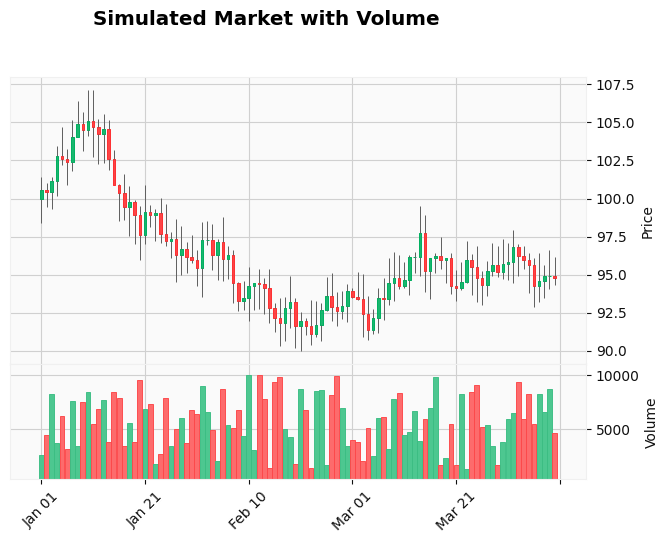

In [7]:
df['Volume'] = np.random.randint(1_000, 10_000, n)

mpf.plot(
    df,
    type='candle',
    style='yahoo',
    volume=True,
    title='Simulated Market with Volume'
)
